# MNIST Convolutional Neural Network (Keras)

  The MNIST training images are all perfectly centred, upright, and similarly sized. This causes the network to overfit to these specific conditions — it learns to recognise a "7" that sits in the middle of the    
  frame at a particular scale, rather than learning what a "7" actually looks like regardless of position, size, or slight rotation. In the real world, handwritten digits won't be perfectly framed, so a model    
  trained only on pristine examples is more brittle than its 99% test accuracy suggests.                                                                                                                              
                                                                                                                                                                                                                    
  Data augmentation fixes this by applying small random transformations (shifts, rotations, zooms) to each training image on the fly, so the network never sees the exact same image twice. This artificially         
  increases the diversity of the training set without collecting new data, and forces the network to learn features that are invariant to position, angle, and scale — which is what we actually want from a digit
  classifier.                                                                                                                                                                                                         
                   

**Architecture:**
`28×28×1 input → Conv(64, 3×3) → MaxPool(2×2) → Conv(64, 3×3) → MaxPool(2×2) → Flatten → Dense(128, tanh) → Dropout(0.3) → Dense(128, tanh) → Dropout(0.3) → Dense(10, softmax)`

**Techniques:** TensorFlow/Keras high-level API · Convolutional + max-pooling layers · ReLU + tanh + softmax activations · Dropout regularisation · Sparse categorical cross-entropy loss · Adam optimiser · `validation_split` + `EarlyStopping` to prevent overfitting

**Classes:** Digits 0–9

This notebook is the Keras counterpart to the from-scratch NumPy MNIST notebook (Network 1). The point is to compare a hand-rolled mini-batch SGD on a plain MLP against the high-level Keras API with a small CNN, and to show the standard tools (dropout, validation split, early stopping) that close the train/test gap.

**Result: ~99.2% test accuracy** 
Final training accuracy : 99.2%  (loss 0.026)
Final validation acc.   : 99.2%  (loss 0.044)
Test accuracy           : 99.2%  (loss 0.024)
Train/test gap          : -0.0%


## Installing Dependencies

In [76]:
%pip install tensorflow -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [77]:
# ── Imports ───────────────────────────────────────────────────────────────
# MNIST dataset loader (ships with Keras)
from keras.datasets import mnist

# TensorFlow / Keras — the deep-learning framework
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Numerical + plotting helpers
import numpy as np
import matplotlib.pyplot as plt

## Loading Our Data

In [78]:
# getting our images
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# getting our training dimensions and counts
training_image_count, training_image_height, training_image_width = x_train.shape[0], x_train.shape[1], x_train.shape[2]

# getting our test dimensions and counts
test_image_count, test_image_height, test_image_width = x_test.shape[0], x_test.shape[1], x_test.shape[2]

## Visualising Augmented Digits

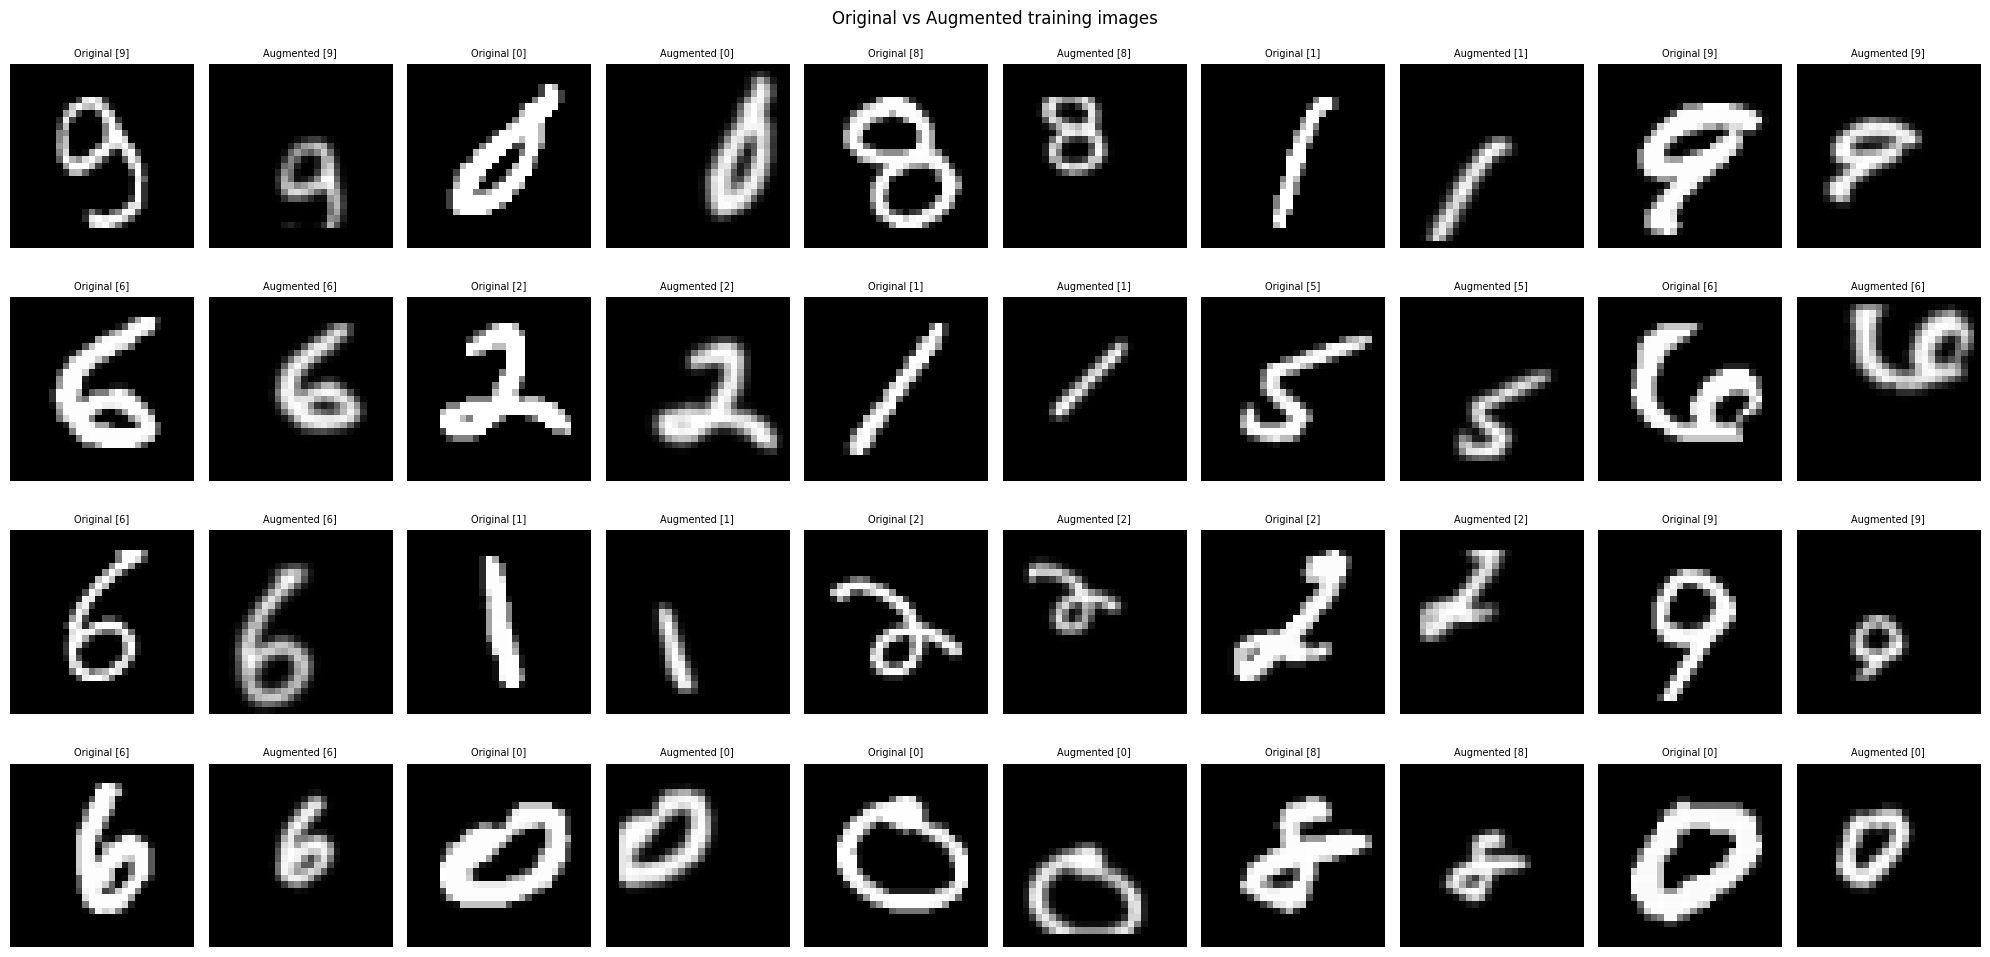

In [99]:
def show_augmented(n=20):
    """Show n random training images alongside their augmented versions."""
    # Build a mini model that ONLY contains the augmentation layers.
    # Calling it in training mode applies the random transforms.
    aug = tf.keras.Sequential([
        tf.keras.layers.RandomRotation(aug_rotation, fill_mode=aug_fill_mode),
        tf.keras.layers.RandomTranslation(*aug_translation, fill_mode=aug_fill_mode),
        tf.keras.layers.RandomZoom(aug_zoom, fill_mode=aug_fill_mode),
    ])

    indices = np.random.randint(0, len(training_images), n)

    cols = 5
    rows = n // cols
    fig, axes = plt.subplots(rows, cols * 2, figsize=(cols * 4, rows * 2.5))

    for i, idx in enumerate(indices):
        row = i // cols
        col = i % cols

        original = training_images[idx]      # (28, 28, 1), already normalised
        augmented = aug(tf.expand_dims(original, 0), training=True)  # (1, 28, 28, 1)
        augmented = augmented[0]             # back to (28, 28, 1)

        # left column: original
        ax_orig = axes[row, col * 2]
        ax_orig.imshow(original[:, :, 0], cmap='gray')
        ax_orig.set_title(f"Original [{y_train[idx]}]", fontsize=7)
        ax_orig.axis('off')

        # right column: augmented
        ax_aug = axes[row, col * 2 + 1]
        ax_aug.imshow(augmented[:, :, 0].numpy(), cmap='gray')
        ax_aug.set_title(f"Augmented [{y_train[idx]}]", fontsize=7)
        ax_aug.axis('off')

    plt.suptitle("Original vs Augmented training images", fontsize=12)
    plt.tight_layout()
    plt.show()

show_augmented()

## Building Our Model

In [98]:
# ── Hyperparameters ───────────────────────────────────────────────────────
input_size  = (training_image_height, training_image_width)  # (28, 28)
hidden_size = 128   # neurons in each fully-connected hidden layer
output_size = 10    # one output per digit class (0–9)
epochs      = 60    # max epochs

# ── Augmentation settings ────────────────────────────────────────────────
aug_rotation    = 0.06          # ±~22 degrees
aug_translation = (0.3, 0.3)   # ±40% shift
aug_zoom        = (0.0, 0.7)   # 0% to 80% smaller
aug_fill_mode   = "constant"   # fill empty space with black

In [100]:
# Training settings 
num_train = 60000
num_test = 10000
batch_size = 100

# EarlyStopping callback settings
callbacks = [EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)]

# Peparing Data
training_images = (x_train[0:num_train] / 255.0).reshape(num_train, training_image_height, training_image_width, 1)
training_labels = y_train[0:num_train]

test_images = (x_test[0:num_test] / 255.0).reshape(num_test, test_image_height, test_image_width, 1)
test_labels = y_test[0:num_test]

In [101]:

# Building The Model
model = tf.keras.models.Sequential([
    # ── Data augmentation ──
    tf.keras.layers.RandomRotation(aug_rotation, fill_mode=aug_fill_mode),
    tf.keras.layers.RandomTranslation(*aug_translation, fill_mode=aug_fill_mode),
    tf.keras.layers.RandomZoom(aug_zoom, fill_mode=aug_fill_mode),

    # ── Convolutional feature extractor ──
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu',input_shape=(training_image_height, training_image_width, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # ── Deep Neural Network ──
    # Layer_0
    tf.keras.layers.Flatten(),

    # Layer_1
    tf.keras.layers.Dense(hidden_size, activation=tf.nn.relu),
    tf.keras.layers.Dropout(0.15),

    # Layer_2
    tf.keras.layers.Dense(hidden_size, activation=tf.nn.relu),
    tf.keras.layers.Dropout(0.15),

    # Output layer:
    tf.keras.layers.Dense(output_size, activation=tf.nn.softmax),
])

# ── Compile ───────────────────────────────────────────────────────────────
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

# ── Train ─────────────────────────────────────────────────────────────────
print("Training…\n")
history = model.fit(training_images, 
                    training_labels,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_split=0.1,
                    callbacks=callbacks,
                    verbose=2)

# ── Evaluate on the held-out test set ─────────────────────────────────────
print("\nEvaluating on test set…")
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)

# ── Final summary ─────────────────────────────────────────────────────────
final_train_accuracy = history.history["accuracy"][-1]
final_train_loss     = history.history["loss"][-1]
final_val_accuracy   = history.history["val_accuracy"][-1]
final_val_loss       = history.history["val_loss"][-1]
epochs_run           = len(history.history["loss"])

print("\n── Results ───────────────────────────────────────────────")
print(f"Epochs run              : {epochs_run} (of {epochs} requested)")
print(f"Final training accuracy : {final_train_accuracy * 100:.1f}%  (loss {final_train_loss:.3f})")
print(f"Final validation acc.   : {final_val_accuracy   * 100:.1f}%  (loss {final_val_loss:.3f})")
print(f"Test accuracy           : {test_accuracy        * 100:.1f}%  (loss {test_loss:.3f})")
print(f"Train/test gap          : {(final_train_accuracy - test_accuracy) * 100:+.1f}%")

Training…

Epoch 1/60


/Users/joehill/Developer/DeepLearning/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


540/540 - 7s - 13ms/step - accuracy: 0.6660 - loss: 0.9804 - val_accuracy: 0.9317 - val_loss: 0.2277
Epoch 2/60
540/540 - 6s - 11ms/step - accuracy: 0.8644 - loss: 0.4277 - val_accuracy: 0.9452 - val_loss: 0.1852
Epoch 3/60
540/540 - 6s - 11ms/step - accuracy: 0.9019 - loss: 0.3106 - val_accuracy: 0.9530 - val_loss: 0.1624
Epoch 4/60
540/540 - 6s - 11ms/step - accuracy: 0.9186 - loss: 0.2609 - val_accuracy: 0.9485 - val_loss: 0.1858
Epoch 5/60
540/540 - 6s - 11ms/step - accuracy: 0.9270 - loss: 0.2324 - val_accuracy: 0.9680 - val_loss: 0.1126
Epoch 6/60
540/540 - 6s - 11ms/step - accuracy: 0.9347 - loss: 0.2070 - val_accuracy: 0.9720 - val_loss: 0.0949
Epoch 7/60
540/540 - 6s - 11ms/step - accuracy: 0.9415 - loss: 0.1890 - val_accuracy: 0.9653 - val_loss: 0.1147
Epoch 8/60
540/540 - 6s - 11ms/step - accuracy: 0.9442 - loss: 0.1751 - val_accuracy: 0.9672 - val_loss: 0.1062
Epoch 9/60
540/540 - 6s - 11ms/step - accuracy: 0.9468 - loss: 0.1672 - val_accuracy: 0.9693 - val_loss: 0.1001
Epo

## Saving Our Model

In [103]:
# saving the model
model.save("mnist_cnn.keras")
print("Saved → mnist_cnn.keras")

Saved → mnist_cnn.keras


## Testing Random Predictions

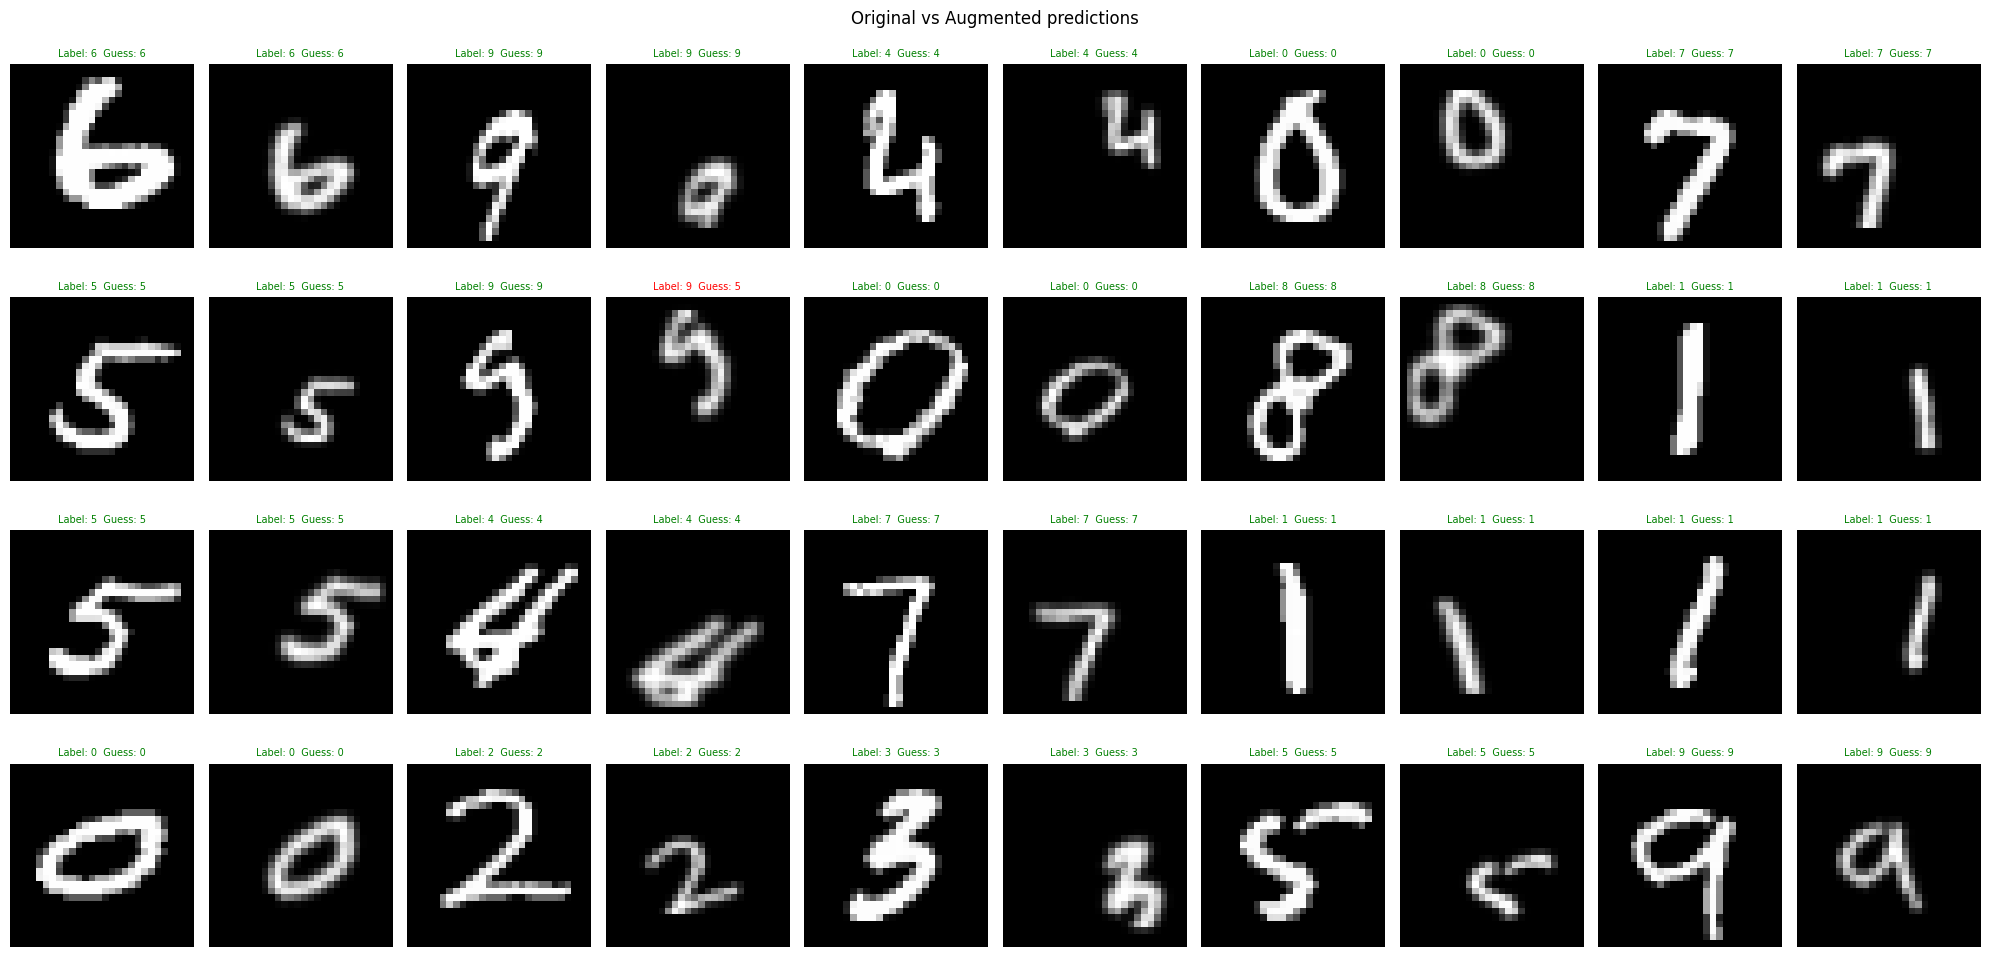

In [102]:
# ── Test 20 random images: original vs augmented ─────────────────────────
def test_20_digits(n=20):
    aug = tf.keras.Sequential([
        tf.keras.layers.RandomRotation(aug_rotation, fill_mode=aug_fill_mode),
        tf.keras.layers.RandomTranslation(*aug_translation, fill_mode=aug_fill_mode),
        tf.keras.layers.RandomZoom(aug_zoom, fill_mode=aug_fill_mode),
    ])

    indices = np.random.randint(0, len(test_images), n)

    cols = 5
    rows = n // cols

    fig, axes = plt.subplots(rows, cols * 2, figsize=(cols * 4, rows * 2.5))

    for i, idx in enumerate(indices):
        row = i // cols
        col = i % cols

        image = test_images[idx]
        true_label = test_labels[idx]

        # augment the image
        augmented = aug(tf.expand_dims(image, 0), training=True)[0]

        # predict on original
        pred_orig = model.predict(image.reshape(1, 28, 28, 1), verbose=0)
        guess_orig = np.argmax(pred_orig)

        # predict on augmented
        pred_aug = model.predict(augmented.numpy().reshape(1, 28, 28, 1), verbose=0)
        guess_aug = np.argmax(pred_aug)

        # left column: original
        ax_orig = axes[row, col * 2]
        ax_orig.imshow(image[:, :, 0], cmap='gray')
        colour = 'green' if guess_orig == true_label else 'red'
        ax_orig.set_title(f"Label: {true_label}  Guess: {guess_orig}", color=colour, fontsize=7)
        ax_orig.axis('off')

        # right column: augmented
        ax_aug = axes[row, col * 2 + 1]
        ax_aug.imshow(augmented[:, :, 0].numpy(), cmap='gray')
        colour = 'green' if guess_aug == true_label else 'red'
        ax_aug.set_title(f"Label: {true_label}  Guess: {guess_aug}", color=colour, fontsize=7)
        ax_aug.axis('off')

    plt.suptitle("Original vs Augmented predictions", fontsize=12)
    plt.tight_layout()
    plt.show()

test_20_digits()